# M1 — Process Mining on Real Production Log

**Data source:** `data/raw/Production_Data.csv` — a real job-shop manufacturing event log  
(~4 500 events, Jan–Mar 2012, multiple product types and machining stations).

**Objective:** Reconstruct the actual production flow end-to-end using process mining,  
then surface where time is lost, which steps cause rework, and how consistent the process is.

**Method principle:** Every number shown is traceable to a specific row in the raw CSV.  
All graphs are built from transparent pandas aggregations — no black-box ML.

---

## Sections
1. [Setup & raw inspection](#1)
2. [Preprocessing & event log construction](#2)
3. [Basic profiling](#3)
4. [Process discovery — Directly-Follows Graph (DFG)](#4)
5. [Cycle time distribution](#5)
6. [Activity time decomposition — where does time go?](#6)
7. [Rework & loop detection](#7)
8. [Process variant analysis](#8)

In [1]:
%matplotlib inline
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pm4py

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

DATA_PATH   = '../data/raw/Production_Data.csv'
FIGURES_DIR = '../reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"pm4py  {pm4py.__version__}")
print(f"pandas {pd.__version__}")
print(f"numpy  {np.__version__}")

C:\Users\User\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


pm4py  2.7.22.5
pandas 2.2.1
numpy  1.26.4


<a id='1'></a>
## 1. Setup & Raw Inspection

We load the raw CSV and inspect its structure before any transformation.

**Column guide**

| Column | Role | Notes |
|---|---|---|
| `Case ID` | Case identifier | One work order = one case |
| `Activity` | Process step / station | Includes machine number |
| `Start Timestamp` | Activity start | ISO-like YYYY/MM/DD HH:MM:SS.mmm |
| `Complete Timestamp` | Activity end | Same format |
| `Span` | Duration (HHH:MM) | Derived — we recompute from timestamps |
| `Resource` | Machine name | More specific than Activity |
| `Worker ID` | Operator | ID-XXXX |
| `Part Desc.` | Product type | Cable Head, Spur Gear, … |
| `Report Type` | Event class | **D** = Done, **S** = Setup, **B** = Breakdown |
| `Qty Completed` | Units finished | Quality metric |
| `Qty Rejected` | Units scrapped | Quality metric |
| `Qty for MRB` | Units in review | Material Review Board |
| `Rework` | Rework flag | Mostly empty |

**Report Type strategy:** Process mining focuses on *what happened to the work item*.  
- **D (Done)** events record the completion of a productive step — these define the process flow.  
- **S (Setup)** events capture machine setup overhead.  
- **B (Breakdown)** events capture machine downtime.  

Sections 3–8 use **D-type events only** for process flow analysis.  
Setup and breakdown durations are noted in profiling but excluded from the DFG and variants  
so the discovered process reflects the production route, not equipment availability.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()   # remove accidental whitespace in headers

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print()
print("Report Type distribution:")
print(df_raw['Report Type'].value_counts())
df_raw.head(6)

Shape: (4543, 14)
Columns: ['Case ID', 'Activity', 'Resource', 'Start Timestamp', 'Complete Timestamp', 'Span', 'Work Order  Qty', 'Part Desc.', 'Worker ID', 'Report Type', 'Qty Completed', 'Qty Rejected', 'Qty for MRB', 'Rework']

Report Type distribution:
Report Type
D    3785
S     705
B      53
Name: count, dtype: int64


,Case ID,Activity,Resource,Start Timestamp,Complete Timestamp,Span,Work Order Qty,Part Desc.,Worker ID,Report Type,Qty Completed,Qty Rejected,Qty for MRB,Rework
0,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/29 23:24:00.000,2012/01/30 05:43:00.000,006:19,10,Cable Head,ID4932,S,1,0,0,NaN
1,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/30 05:44:00.000,2012/01/30 06:42:00.000,000:58,10,Cable Head,ID4932,D,1,0,0,NaN
2,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/30 06:59:00.000,2012/01/30 07:21:00.000,000:22,10,Cable Head,ID4167,S,0,0,0,NaN
3,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/30 07:21:00.000,2012/01/30 10:58:00.000,003:37,10,Cable Head,ID4167,D,8,0,0,NaN
4,Case 1,Turning & Milling Q.C.,Quality Check 1,2012/01/31 13:20:00.000,2012/01/31 14:50:00.000,001:30,10,Cable Head,ID4163,D,9,1,0,NaN
5,Case 1,Laser Marking - Machine 7,Machine 7- Laser Marking,2012/02/01 08:18:00.000,2012/02/01 08:27:00.000,000:09,10,Cable Head,ID0998,D,9,0,0,NaN


<a id='2'></a>
## 2. Preprocessing & Event Log Construction

Steps:
1. Parse both timestamp columns to `datetime64`.
2. Compute `processing_hours` per event row (clipped to 0 for any negative durations).
3. Sort by case → start time so within-case ordering is deterministic.
4. Split into **full log** (all Report Types) and **D-only log** used for process flow analysis.

In [3]:
df = df_raw.copy()

for col in ['Start Timestamp', 'Complete Timestamp']:
    df[col] = pd.to_datetime(df[col], format='%Y/%m/%d %H:%M:%S.%f')

df['processing_hours'] = (
    (df['Complete Timestamp'] - df['Start Timestamp'])
    .dt.total_seconds() / 3600
).clip(lower=0)

df = df.sort_values(['Case ID', 'Start Timestamp']).reset_index(drop=True)

# D-only: primary analysis log
df_D = df[df['Report Type'] == 'D'].copy().reset_index(drop=True)

print(f"Total events   : {len(df):,}")
print(f"D-type (Done)  : {len(df_D):,}  ({len(df_D)/len(df)*100:.1f}%)")
print(f"S-type (Setup) : {(df['Report Type']=='S').sum():,}")
print(f"B-type (Break) : {(df['Report Type']=='B').sum():,}")
print()
print(f"processing_hours summary (D-type):")
print(df_D['processing_hours'].describe().round(2))

Total events   : 4,543
D-type (Done)  : 3,785  (83.3%)
S-type (Setup) : 705
B-type (Break) : 53

processing_hours summary (D-type):
count    3785.00
mean        2.99
std         3.17
min         0.00
25%         1.00
50%         1.58
75%         4.17
max        23.42
Name: processing_hours, dtype: float64


<a id='3'></a>
## 3. Basic Profiling

Before mining the process we establish ground facts: how many cases, how many steps per case,  
which stations are most active, and what the product mix looks like.

**What to look for:**
- A small number of activities handling most events → concentrated flow.
- High variance in events-per-case → cases follow very different routes (rework, product mix).
- Product-type imbalance → the dominant product may drive the global cycle-time picture.

In [4]:
n_cases  = df_D['Case ID'].nunique()
n_events = len(df_D)
n_acts   = df_D['Activity'].nunique()
n_prods  = df_D['Part Desc.'].nunique()
t0 = df['Start Timestamp'].min()
t1 = df['Complete Timestamp'].max()

print("=" * 48)
print(f"{'Metric':<30} {'Value':>10}")
print("=" * 48)
print(f"{'Unique cases':<30} {n_cases:>10,}")
print(f"{'D-type events':<30} {n_events:>10,}")
print(f"{'Unique activities':<30} {n_acts:>10}")
print(f"{'Product types':<30} {n_prods:>10}")
print(f"{'Log start':<30} {str(t0.date()):>10}")
print(f"{'Log end':<30} {str(t1.date()):>10}")
print(f"{'Span (days)':<30} {(t1-t0).days:>10}")
print("=" * 48)

epc = df_D.groupby('Case ID').size()
print(f"\nEvents/case — mean: {epc.mean():.1f}  "
      f"median: {epc.median():.0f}  "
      f"max: {epc.max()}")

Metric                              Value
Unique cases                          222
D-type events                       3,785
Unique activities                      51
Product types                          43
Log start                      2012-01-02
Log end                        2012-03-31
Span (days)                            89

Events/case — mean: 17.0  median: 12  max: 167


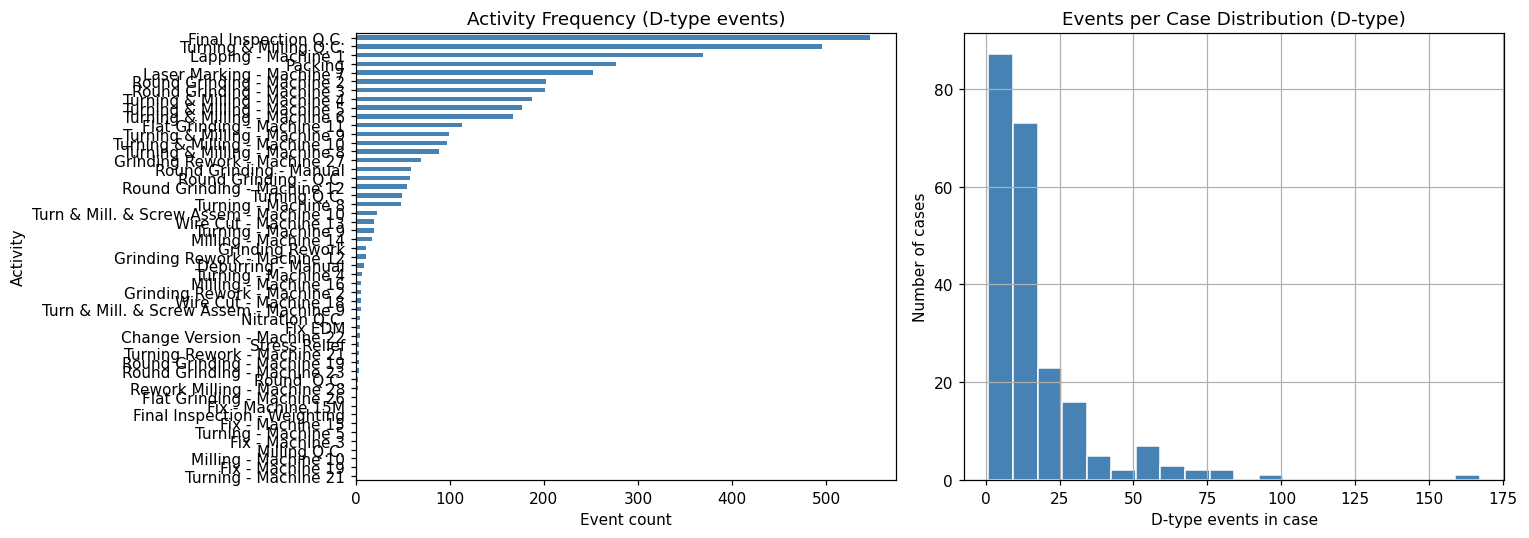


Product-type: distinct cases
Part Desc.
Ballnut               58
Cable Head            49
Spur Gear             26
Bearing               11
Housing                9
Plug                   6
Piston                 4
Clamp                  3
Drill                  3
Punch Holder           3
Gauge                  3
Spring                 3
Ring                   2
Punch Plate            2
Adjusting Nut          2
Spinner                2
Tube                   2
O-Ring                 2
Socket                 2
Wheel Shaft            2
Fastener               2
Electrical Contact     2
Drum                   2
Bushing                2
Flange                 2
Flange Bolt            1
Slip Ring Adapter      1
Wheel                  1
Assembly 1             1
Barrel                 1
Blade                  1
Spindle                1
Cast                   1
Compound Dies          1
Shim                   1
Seal Head              1
Cutting Wheel          1
Cylinder               1
Disc     

In [5]:
act_freq = df_D['Activity'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Activity frequency (horizontal bar)
act_freq.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Activity Frequency (D-type events)')
axes[0].set_xlabel('Event count')
axes[0].invert_yaxis()

# Events per case histogram
epc.hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Events per Case Distribution (D-type)')
axes[1].set_xlabel('D-type events in case')
axes[1].set_ylabel('Number of cases')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/profiling_overview.png', bbox_inches='tight')
plt.show()

print("\nProduct-type: distinct cases")
print(df_D.groupby('Part Desc.')['Case ID'].nunique().sort_values(ascending=False))

**Profiling interpretation:**

The activity frequency bar chart immediately shows which stations handle the most work.  
A long right tail in events-per-case (or a high max vs. median ratio) signals rework or  
multi-batch splitting within cases — we will quantify this in Section 7.

The product mix (case count by `Part Desc.`) tells us whether the log is dominated by  
a single part family or is genuinely multi-product, which matters for variant analysis.

<a id='4'></a>
## 4. Process Discovery — Directly-Follows Graph (DFG)

A **Directly-Follows Graph (DFG)** answers: *given that activity A occurred in a case,  
which activity B immediately followed it, and how often?*

We build the DFG by:
1. Sorting each case's events by `Start Timestamp`.
2. Recording every consecutive (A → B) transition and collecting its waiting time  
   (= `Start_B − Complete_A`, clipped to 0 if activities overlap).
3. Summarising each edge as **frequency** (count) + **median waiting time** (hours).

**Edge reading guide:**  
`N× / W.Wh` means the transition occurred N times; the median gap before the next step  
was W.W hours.  A long wait on a high-frequency edge = a systemic queue = bottleneck candidate.

**Node colour:**  
- Green = first activity in cases  
- Red = last activity  
- Orange = both start and end  
- Blue = intermediate step

In [6]:
def build_dfg(df_events):
    """Build directly-follows graph from a sorted event dataframe.

    Returns
    -------
    dfg_freq      : {(A, B): int}     transition counts
    dfg_med_wait  : {(A, B): float}   median waiting hours per edge
    start_acts    : {activity: count}
    end_acts      : {activity: count}
    """
    dfg_freq   = {}
    dfg_waits  = {}
    start_acts = {}
    end_acts   = {}

    for case_id, grp in df_events.groupby('Case ID', sort=False):
        grp = grp.sort_values('Start Timestamp').reset_index(drop=True)
        acts      = grp['Activity'].tolist()
        starts    = grp['Start Timestamp'].tolist()
        completes = grp['Complete Timestamp'].tolist()

        if not acts:
            continue

        start_acts[acts[0]]  = start_acts.get(acts[0], 0)  + 1
        end_acts[acts[-1]]   = end_acts.get(acts[-1], 0)   + 1

        for i in range(len(acts) - 1):
            pair = (acts[i], acts[i + 1])
            dfg_freq[pair] = dfg_freq.get(pair, 0) + 1
            wait_h = max(0.0,
                         (starts[i + 1] - completes[i]).total_seconds() / 3600)
            dfg_waits.setdefault(pair, []).append(wait_h)

    dfg_med_wait = {p: float(np.median(v)) for p, v in dfg_waits.items()}
    return dfg_freq, dfg_med_wait, start_acts, end_acts


def shorten_label(name, max_chars=20):
    """Create a compact activity label for DFG node/edge display."""
    abbrevs = [
        ('Turning & Milling', 'T&M'),
        ('Round Grinding', 'R.Grind'),
        ('Flat Grinding', 'F.Grind'),
        ('Grinding Rework', 'Grind Rwk'),
        ('Laser Marking', 'Laser'),
        ('Final Inspection Q.C.', 'Final QC'),
        ('Quality Check', 'QC'),
        ('Q.C.', 'QC'),
        ('Inspection', 'Insp'),
    ]
    s = str(name)
    for long, short in abbrevs:
        s = s.replace(long, short)
    s = re.sub(r'\s*-\s*Machine\s+(\d+)', r' (M\1)', s)
    s = re.sub(r'\s*-\s*Manual', ' Manual', s)
    s = s.strip()
    if len(s) > max_chars:
        s = s[:max_chars - 1] + '\u2026'
    return s


# Build DFG from D-type events
dfg_freq, dfg_med_wait, start_acts, end_acts = build_dfg(df_D)

all_nodes = {n for pair in dfg_freq for n in pair}
label_map = {n: shorten_label(n) for n in all_nodes}

print(f"DFG: {len(dfg_freq)} unique transitions across {len(all_nodes)} nodes")
print()
print("Top 10 transitions by frequency:")
print(f"  {'From':<40} {'To':<40} {'Freq':>6}  {'Med wait (h)':>12}")
print("  " + "-" * 105)
for (a, b), cnt in sorted(dfg_freq.items(), key=lambda x: -x[1])[:10]:
    print(f"  {label_map[a]:<40} {label_map[b]:<40} {cnt:>6}  "
          f"{dfg_med_wait[(a,b)]:>12.1f}")

DFG: 363 unique transitions across 51 nodes

Top 10 transitions by frequency:
  From                                     To                                         Freq  Med wait (h)
  ---------------------------------------------------------------------------------------------------------
  Final QC                                 Final QC                                    200           1.3
  Final QC                                 Packing                                     145          11.3
  Packing                                  Final QC                                    123           7.7
  T&M QC                                   T&M QC                                      116           4.5
  Lapping (M1)                             Lapping (M1)                                115           5.9
  R.Grind (M3)                             R.Grind (M3)                                114           0.4
  T&M (M4)                                 T&M (M4)                            

Saved -> ../reports/figures/dfg_real_log.png


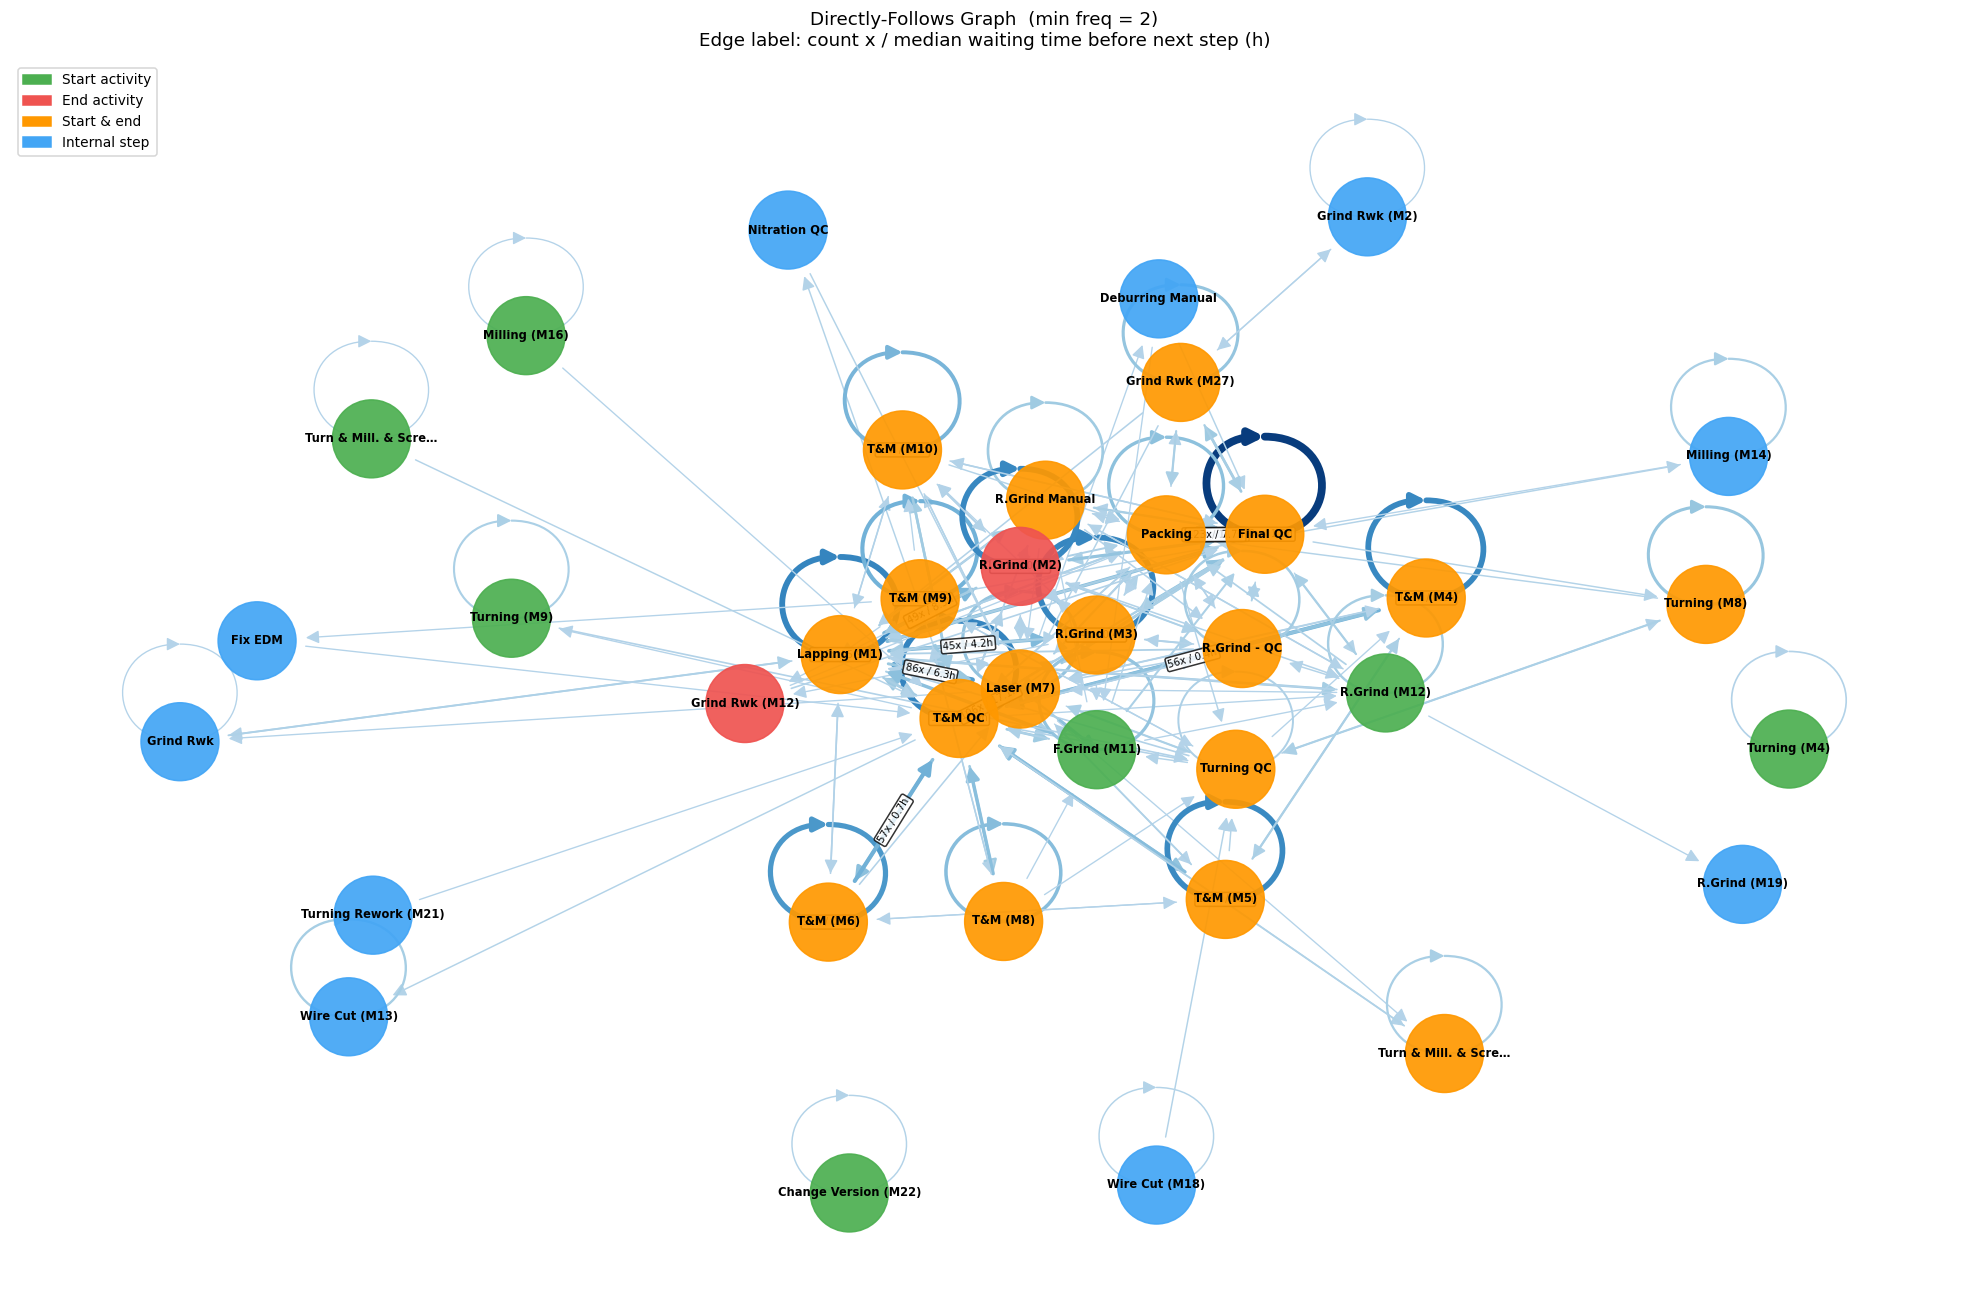

In [7]:
def draw_dfg(dfg_freq, dfg_med_wait, label_map, start_acts, end_acts,
             min_freq=2, top_label_edges=18, figsize=(18, 12), save_path=None):
    """Render DFG using networkx + matplotlib.

    Edge width proportional to sqrt(frequency).
    Edge colour: light -> dark blue with frequency.
    Labels shown only for the top_label_edges highest-frequency edges.
    """
    G = nx.DiGraph()
    for (a, b), freq in dfg_freq.items():
        if freq >= min_freq:
            G.add_edge(a, b, freq=freq, wait=dfg_med_wait.get((a, b), 0.0))

    if not G.nodes:
        print(f"No edges with freq >= {min_freq}.")
        return G

    # Layout: prefer graphviz hierarchical, fall back to spring
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=3.0, iterations=200)

    freqs   = [G[u][v]['freq'] for u, v in G.edges()]
    max_f   = max(freqs) if freqs else 1
    widths  = [0.6 + 4.5 * (f / max_f) ** 0.6 for f in freqs]
    ecols   = [plt.cm.Blues(0.30 + 0.65 * (f / max_f)) for f in freqs]

    def node_color(n):
        is_s = n in start_acts
        is_e = n in end_acts
        if is_s and not is_e:  return '#4CAF50'
        if is_e and not is_s:  return '#EF5350'
        if is_s and is_e:      return '#FF9800'
        return '#42A5F5'

    ncolors = [node_color(n) for n in G.nodes()]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('#F8F9FA')

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=ncolors,
                           node_size=2600, alpha=0.92)
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        labels={n: label_map.get(n, shorten_label(n)) for n in G.nodes()},
        font_size=7.5, font_weight='bold'
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        width=widths, edge_color=ecols,
        arrows=True, arrowsize=18,
        min_source_margin=32, min_target_margin=32
    )

    # Label only the most frequent edges to avoid clutter
    top_pairs = sorted(G.edges(data=True), key=lambda e: e[2]['freq'], reverse=True)
    top_pairs = top_pairs[:top_label_edges]
    edge_labels = {
        (u, v): f"{data['freq']}x / {data['wait']:.1f}h"
        for u, v, data in top_pairs
    }
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, ax=ax,
        font_size=6.5,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.80)
    )

    legend_handles = [
        mpatches.Patch(color='#4CAF50', label='Start activity'),
        mpatches.Patch(color='#EF5350', label='End activity'),
        mpatches.Patch(color='#FF9800', label='Start & end'),
        mpatches.Patch(color='#42A5F5', label='Internal step'),
    ]
    ax.legend(handles=legend_handles, loc='upper left', fontsize=9)
    ax.set_title(
        f'Directly-Follows Graph  (min freq = {min_freq})\n'
        'Edge label: count x / median waiting time before next step (h)',
        fontsize=12, pad=10
    )
    ax.axis('off')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved -> {save_path}")
    plt.show()
    return G


G = draw_dfg(
    dfg_freq, dfg_med_wait, label_map, start_acts, end_acts,
    min_freq=2,
    save_path=f'{FIGURES_DIR}/dfg_real_log.png'
)

**DFG interpretation:**

The DFG shows the *empirical* production flow — not the designed one, but what actually happened.  
Key things to note:

- **Dominant path (thick dark edges):** the most common sequence of steps.  
  This is the *happy path* — what happens when production goes smoothly.
- **Back-edges / cycles:** an edge pointing backward in the layout signals a rework loop  
  (the part returned to a previous station). We quantify these in Section 7.
- **Long median wait on a high-frequency edge:** the receiving station cannot keep up  
  with the rate of arrivals from the upstream step — a textbook Theory-of-Constraints bottleneck.  
  We will rank these systematically in Section 6.
- **Fan-out nodes (many outgoing edges):** routing decisions or inspection outcomes  
  (pass/fail → different next step).
- **Fan-in nodes (many incoming edges):** shared resources — machines that serve  
  multiple product types or routes.

<a id='5'></a>
## 5. Cycle Time Distribution

**Cycle time** = the wall-clock time from when work on a case first *starts*  
to when the last step *completes*.  
It includes all waiting, queuing, setup, and processing — the total lead time experienced by the part.

We compute it from **all Report Types** (including Setup and Breakdown)  
to capture the full elapsed time, then break it out by product type to detect  
whether different parts follow fundamentally different schedules.

Cycle Time (hours) — all cases:
count     225.0
mean      494.9
std       506.7
min         0.5
25%       131.7
50%       333.6
75%       693.6
max      2098.9
Name: cycle_hours, dtype: float64

Median  : 333.6 h  = 13.9 days
Mean    : 494.9 h  = 20.6 days
P90     : 1136.0 h  = 47.3 days
P99     : 2057.9 h  = 85.7 days


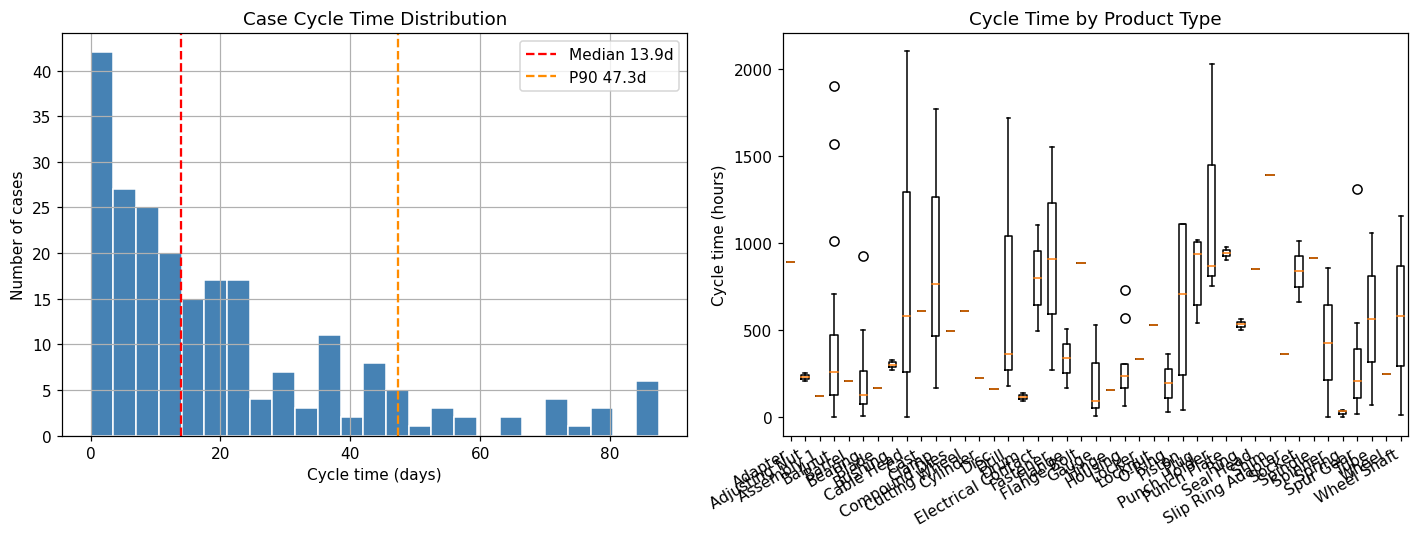

In [8]:
# Cycle time = earliest start to latest complete, per case (all Report Types)
cycle_df = (
    df.groupby('Case ID')
    .agg(case_start=('Start Timestamp', 'min'),
         case_end=('Complete Timestamp', 'max'))
)
cycle_df['cycle_hours'] = (
    (cycle_df['case_end'] - cycle_df['case_start'])
    .dt.total_seconds() / 3600
)
ct = cycle_df['cycle_hours']

print("Cycle Time (hours) — all cases:")
print(ct.describe().round(1))
print()
print(f"Median  : {ct.median():.1f} h  = {ct.median()/24:.1f} days")
print(f"Mean    : {ct.mean():.1f} h  = {ct.mean()/24:.1f} days")
print(f"P90     : {ct.quantile(0.90):.1f} h  = {ct.quantile(0.90)/24:.1f} days")
print(f"P99     : {ct.quantile(0.99):.1f} h  = {ct.quantile(0.99)/24:.1f} days")

# Attach product type from D events
prod_map = df_D.groupby('Case ID')['Part Desc.'].first()
cycle_df = cycle_df.join(prod_map, how='left')

products = sorted(cycle_df['Part Desc.'].dropna().unique())
data_by_prod = [
    cycle_df.loc[cycle_df['Part Desc.'] == p, 'cycle_hours'].values
    for p in products
]

ct_days = ct / 24
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_days.hist(bins=25, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(ct_days.median(), color='red', linestyle='--',
                label=f'Median {ct_days.median():.1f}d')
axes[0].axvline(ct_days.quantile(0.9), color='darkorange', linestyle='--',
                label=f'P90 {ct_days.quantile(0.9):.1f}d')
axes[0].set_xlabel('Cycle time (days)')
axes[0].set_ylabel('Number of cases')
axes[0].set_title('Case Cycle Time Distribution')
axes[0].legend()

axes[1].boxplot(data_by_prod, labels=products)
axes[1].set_xticklabels(products, rotation=30, ha='right')
axes[1].set_ylabel('Cycle time (hours)')
axes[1].set_title('Cycle Time by Product Type')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cycle_time.png', bbox_inches='tight')
plt.show()

**Cycle time findings:**

The histogram shape tells us about process stability:
- **Unimodal, narrow:** stable process — most cases take roughly the same time.
- **Long right tail or bimodal:** some cases take much longer — rework, expediting, or  
  fundamentally different product routing.

The per-product boxplot highlights whether different part families have genuinely  
different lead times. A large spread within a single product type signals inconsistent  
scheduling or rework patterns for that part.  
High mean-vs-median ratio confirms a few extreme outliers are pulling the average up.

<a id='6'></a>
## 6. Activity Time Decomposition — Where Does Time Go?

Every hour spent in the plant is either:
- **Processing time:** the machine is working on the part (= `Complete - Start` per event).
- **Waiting time:** the part is sitting in queue between steps  
  (= `Start of next step - Complete of previous step`, within the same case).

Aggregating both across all cases for each activity reveals the true time budget:  
a step with high *waiting* absorbed by upstream cases is a **bottleneck**  
in the Theory-of-Constraints sense — it receives work faster than it can process it.

> **Note:** waiting time is attributed to the *receiving* step  
> (the step that was waited for), not the preceding step.

In [9]:
# Processing time per activity (D-type events)
proc_stats = (
    df_D.groupby('Activity')['processing_hours']
    .agg(n='count', total_proc='sum', median_proc='median', mean_proc='mean')
    .sort_values('total_proc', ascending=False)
)

# Waiting time: from previous step's Complete to this step's Start (same case)
df_D_s = df_D.sort_values(['Case ID', 'Start Timestamp']).copy()
df_D_s['prev_complete'] = (
    df_D_s.groupby('Case ID')['Complete Timestamp'].shift(1)
)
df_D_s['waiting_hours'] = (
    (df_D_s['Start Timestamp'] - df_D_s['prev_complete'])
    .dt.total_seconds() / 3600
).clip(lower=0)

wait_stats = (
    df_D_s.dropna(subset=['waiting_hours'])
    .groupby('Activity')['waiting_hours']
    .agg(total_wait='sum', median_wait='median', mean_wait='mean')
    .sort_values('total_wait', ascending=False)
)

combined = proc_stats.join(wait_stats, how='outer').fillna(0)
combined['short'] = [
    label_map.get(idx, shorten_label(idx)) for idx in combined.index
]
combined_sorted = combined.sort_values('total_wait', ascending=False)

print("Activity time decomposition (top 12 by total waiting time):")
print()
print(f"  {'Activity':<40} {'n':>5}  {'Tot Wait(h)':>12}  "
      f"{'Med Wait(h)':>12}  {'Tot Proc(h)':>12}  {'Med Proc(h)':>12}")
print("  " + "-" * 100)
for act, row in combined_sorted.head(12).iterrows():
    print(f"  {label_map.get(act, shorten_label(act)):<40} "
          f"{int(row['n']):>5}  "
          f"{row['total_wait']:>12.1f}  "
          f"{row['median_wait']:>12.1f}  "
          f"{row['total_proc']:>12.1f}  "
          f"{row['median_proc']:>12.1f}")

Activity time decomposition (top 12 by total waiting time):

  Activity                                     n   Tot Wait(h)   Med Wait(h)   Tot Proc(h)   Med Proc(h)
  ----------------------------------------------------------------------------------------------------
  Lapping (M1)                               369       20401.2           2.1         656.0           1.2
  Final QC                                   547       15318.7           7.2        1047.0           1.2
  T&M QC                                     496       11441.7           1.8         754.8           1.2
  Laser (M7)                                 252        9183.2           4.0         242.6           0.9
  Packing                                    277        8230.4          10.0         277.0           1.0
  Grind Rwk (M27)                             69        5309.3          13.5         180.6           2.0
  R.Grind (M2)                               202        3321.3           1.0         897.5           

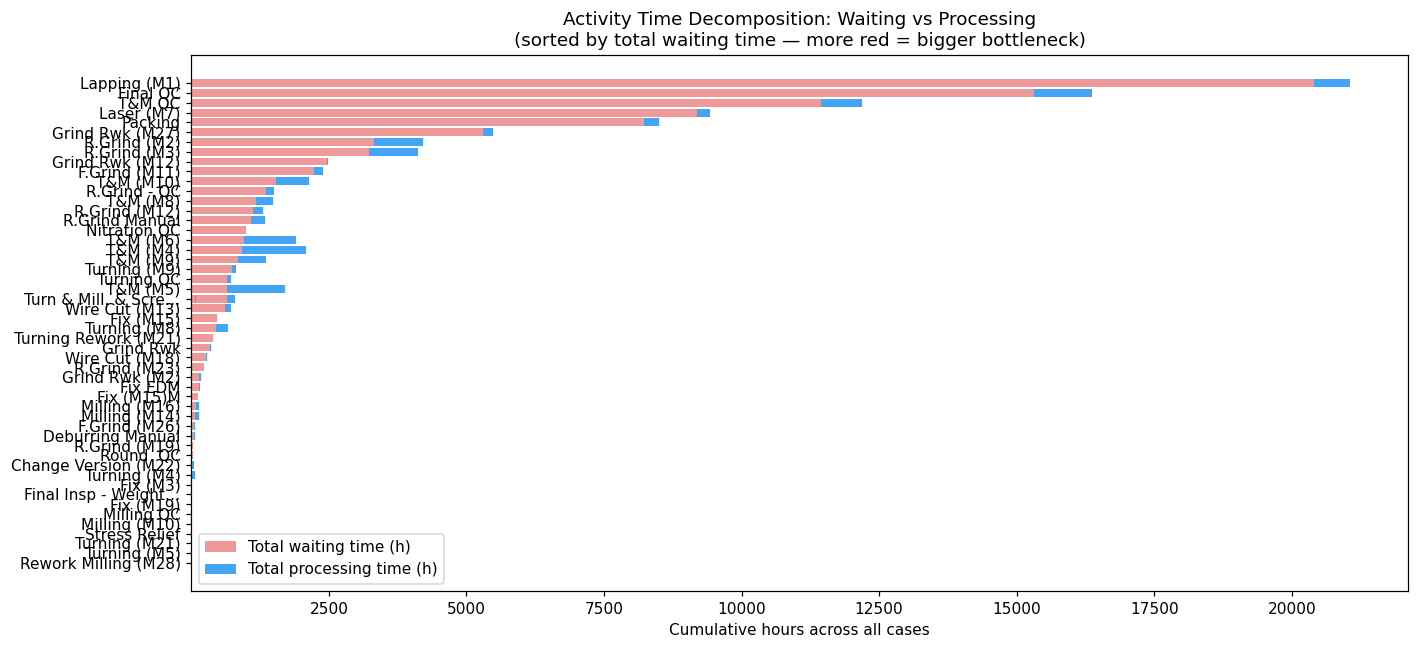

Top bottleneck: Lapping (M1)
  Total wait : 20401 h
  Total proc : 656 h
  Wait/proc  : 31.10x  (>1 means queue dominates)


In [10]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.barh(combined_sorted['short'], combined_sorted['total_wait'],
        color='#EF9A9A', label='Total waiting time (h)')
ax.barh(combined_sorted['short'], combined_sorted['total_proc'],
        left=combined_sorted['total_wait'],
        color='#42A5F5', label='Total processing time (h)')

ax.set_xlabel('Cumulative hours across all cases')
ax.set_title(
    'Activity Time Decomposition: Waiting vs Processing\n'
    '(sorted by total waiting time — more red = bigger bottleneck)'
)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/activity_time_decomposition.png', bbox_inches='tight')
plt.show()

top1 = combined_sorted.index[0]
top1_wait = combined_sorted.loc[top1, 'total_wait']
top1_proc = combined_sorted.loc[top1, 'total_proc']
top1_ratio = top1_wait / max(top1_proc, 1e-9)
print(f"Top bottleneck: {label_map.get(top1, shorten_label(top1))}")
print(f"  Total wait : {top1_wait:.0f} h")
print(f"  Total proc : {top1_proc:.0f} h")
print(f"  Wait/proc  : {top1_ratio:.2f}x  (>1 means queue dominates)")

**Bottleneck interpretation:**

The stacked bar chart ranks activities by **total waiting time** — the cumulative time  
that all cases spent sitting idle before reaching each step.

- A step where the red bar (waiting) dwarfs the blue bar (processing) is overloaded:  
  work arrives faster than it can be processed — classic bottleneck.
- A step with high processing but low waiting is busy but not a bottleneck —  
  it keeps up with demand.
- A step with low totals (short bar overall) is underutilised and not critical.

This analysis is the real-data analogue of the **utilisation-based bottleneck detection**  
we validated against synthetic ground truth in M2 (S4 at ~85% utilisation).  
For M4 we will formalise the detection criterion and compare synthetic vs real.

<a id='7'></a>
## 7. Rework & Loop Detection

**Rework** in a process log appears as a case where the *same activity name* occurs more than once.  
This covers:
- **Self-loops:** the activity immediately follows itself (e.g., a partial batch finished, then continued).
- **Rework loops:** the case went forward, failed inspection, and returned to an earlier step.

We also correlate rework with quality metrics (`Qty Rejected`, `Qty for MRB`)  
to test whether rework cases show higher rejection rates.

In [11]:
# Count occurrences of each (Case ID, Activity) pair
act_per_case = (
    df_D.groupby(['Case ID', 'Activity'])
    .size()
    .reset_index(name='occurrences')
)
rework = act_per_case[act_per_case['occurrences'] > 1]

n_rework_cases  = rework['Case ID'].nunique()
n_total_cases   = df_D['Case ID'].nunique()
extra_events    = int((rework['occurrences'] - 1).sum())

print(f"Cases with rework: {n_rework_cases} / {n_total_cases}  "
      f"({n_rework_cases/n_total_cases*100:.1f}%)")
print(f"Extra rework events: {extra_events}")
print()

rework_by_act = (
    rework.groupby('Activity')
    .agg(
        affected_cases=('Case ID', 'nunique'),
        extra_events=('occurrences', lambda x: int((x - 1).sum()))
    )
    .sort_values('affected_cases', ascending=False)
)
rework_by_act['short'] = [
    label_map.get(i, shorten_label(i)) for i in rework_by_act.index
]

print("Activities generating the most rework:")
print(rework_by_act[['short', 'affected_cases', 'extra_events']].to_string(index=False))

Cases with rework: 199 / 222  (89.6%)
Extra rework events: 2445

Activities generating the most rework:
               short  affected_cases  extra_events
            Final QC             112           371
              T&M QC             111           328
        Lapping (M1)              82           237
             Packing              54           102
          Laser (M7)              49            85
        R.Grind (M2)              37           157
        R.Grind (M3)              31           158
       F.Grind (M11)              25            55
            T&M (M8)              25            55
            T&M (M4)              24           154
            T&M (M6)              24           128
            T&M (M5)              22           146
            T&M (M9)              17            80
      R.Grind Manual              15            35
           T&M (M10)              14            80
       R.Grind (M12)              14            32
          Turning QC         

In [12]:
# Self-loops: A -> A consecutive transitions
self_loops = {(a, b): cnt for (a, b), cnt in dfg_freq.items() if a == b}
print(f"Self-loops in DFG: {len(self_loops)}")
for (a, _), cnt in sorted(self_loops.items(), key=lambda x: -x[1]):
    print(f"  {label_map.get(a, shorten_label(a))}: {cnt} times")

print()

# Quality correlation: rework cases vs normal cases
rework_ids = set(rework['Case ID'])
df_D['has_rework'] = df_D['Case ID'].isin(rework_ids)

quality = (
    df_D.groupby('has_rework')[['Qty Rejected', 'Qty for MRB', 'Qty Completed']]
    .sum()
)
quality['reject_rate'] = (
    quality['Qty Rejected'] /
    (quality['Qty Rejected'] + quality['Qty Completed'])
).round(3)
quality.index = quality.index.map({False: 'Normal cases', True: 'Rework cases'})

print("Quality metrics by rework status:")
print(quality)

Self-loops in DFG: 33
  Final QC: 200 times
  T&M QC: 116 times
  Lapping (M1): 115 times
  R.Grind (M3): 114 times
  T&M (M4): 111 times
  R.Grind (M2): 111 times
  T&M (M5): 109 times
  T&M (M6): 91 times
  T&M (M9): 56 times
  T&M (M10): 51 times
  T&M (M8): 40 times
  Packing: 36 times
  Laser (M7): 31 times
  F.Grind (M11): 31 times
  Grind Rwk (M27): 30 times
  Turning (M8): 29 times
  R.Grind Manual: 21 times
  R.Grind - QC: 18 times
  R.Grind (M12): 16 times
  Wire Cut (M13): 15 times
  Milling (M14): 13 times
  Turn & Mill. & Scre…: 13 times
  Turning (M9): 11 times
  Turning QC: 9 times
  Turning (M4): 5 times
  Wire Cut (M18): 3 times
  Change Version (M22): 3 times
  Grind Rwk: 2 times
  Grind Rwk (M2): 2 times
  Turn & Mill. & Scre…: 2 times
  Milling (M16): 2 times
  R.Grind (M19): 1 times
  Grind Rwk (M12): 1 times

Quality metrics by rework status:
              Qty Rejected  Qty for MRB  Qty Completed  reject_rate
has_rework                                             

**Rework findings interpretation:**

The rework rate (% of cases that repeat at least one activity) quantifies how often the  
process deviates from a single-pass flow.  
In job-shop manufacturing, some rework is expected; the key questions are:

1. **Which station causes most rework?** — If a QC step precedes the top rework station,  
   it is the inspection gate; if a machining step is top, the process is unreliable at that step.
2. **Do rework cases show higher rejection rates?** — If `reject_rate` is notably higher  
   for rework cases, rework is a genuine quality signal. If not, rework may reflect  
   batch splitting or scheduling artifacts rather than quality failures.
3. **Self-loops** — Consecutive repeats of the same activity usually mean the work order  
   was split across multiple operators/shifts and logged as separate D events.  
   They inflate the event count but may not represent true process failures.

<a id='8'></a>
## 8. Process Variant Analysis

A **process variant** is the ordered sequence of activities that a case actually followed.  
If all cases followed exactly the same route, there would be exactly one variant.  
In practice, different products, rework events, and skip steps create many variants.

We:
1. Extract the activity sequence per case (sorted by `Start Timestamp`).
2. Count how many cases follow each distinct variant.
3. Compute cumulative coverage: how many distinct variants are needed to cover  
   80% / 95% of all cases?

In [13]:
def extract_variants(df_events):
    """Return {case_id: (activity_sequence,)} sorted by Start Timestamp."""
    result = {}
    for case_id, grp in df_events.groupby('Case ID', sort=False):
        seq = tuple(grp.sort_values('Start Timestamp')['Activity'].tolist())
        result[case_id] = seq
    return result


case_variants   = extract_variants(df_D)
variant_series  = pd.Series(list(case_variants.values()))
variant_counts  = variant_series.value_counts()

n_total  = len(case_variants)
n_unique = len(variant_counts)

print(f"Total cases      : {n_total}")
print(f"Unique variants  : {n_unique}")
print(f"Top-1 share      : {variant_counts.iloc[0]/n_total:.1%}")
print()
print(f"{'Rank':<5} {'Cases':>6} {'%':>6}  Path")
print("-" * 90)
for rank, (variant, count) in enumerate(variant_counts.head(10).items(), 1):
    path = ' -> '.join(
        label_map.get(a, shorten_label(a)) for a in variant
    )
    print(f"{rank:<5} {count:>6} {count/n_total*100:>5.1f}%  {path}")

Total cases      : 222
Unique variants  : 217
Top-1 share      : 1.8%

Rank   Cases      %  Path
------------------------------------------------------------------------------------------
1          4   1.8%  Packing -> Final QC
2          2   0.9%  T&M (M4) -> T&M (M4)
3          2   0.9%  T&M (M6) -> T&M QC
4          1   0.5%  T&M (M4) -> T&M (M4) -> T&M QC -> Laser (M7) -> Lapping (M1) -> Lapping (M1) -> Lapping (M1) -> Lapping (M1) -> R.Grind (M3) -> Final QC -> Final QC -> Final QC -> Packing
5          1   0.5%  T&M (M8) -> T&M (M8) -> T&M (M8) -> T&M QC -> Lapping (M1) -> R.Grind Manual -> Laser (M7) -> Final QC -> Packing -> Final QC
6          1   0.5%  T&M (M9) -> T&M (M9) -> T&M QC -> F.Grind (M11) -> T&M QC -> Laser (M7) -> Lapping (M1) -> R.Grind (M3) -> R.Grind (M3) -> Final QC -> Packing -> Final QC -> Final QC
7          1   0.5%  T&M (M9) -> T&M (M9) -> T&M QC -> F.Grind (M11) -> Laser (M7) -> Lapping (M1) -> R.Grind (M12) -> R.Grind (M12) -> Packing -> Final QC -> Fi

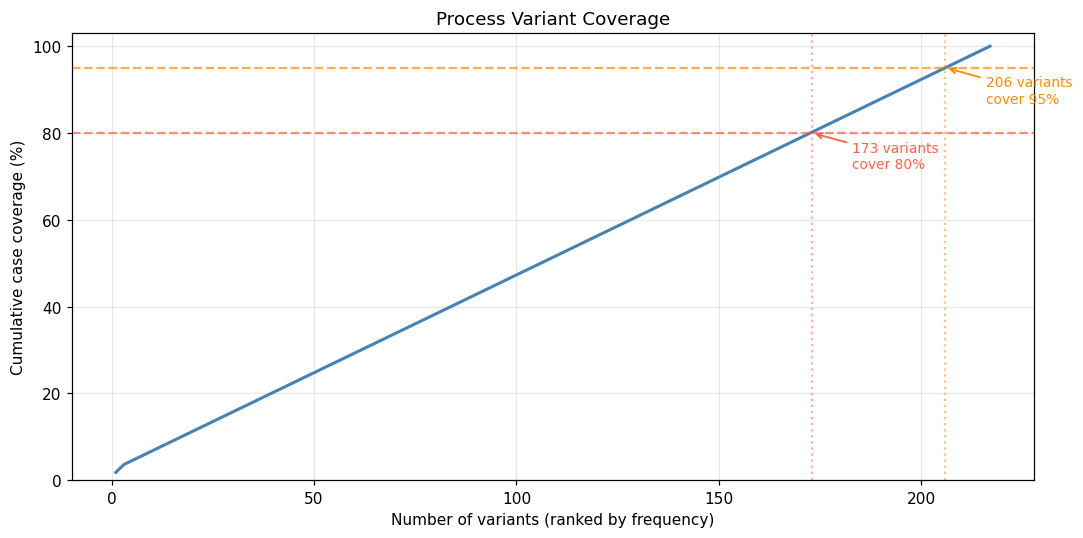

Variants needed to cover 80% of cases : 173
Variants needed to cover 95% of cases : 206
Singleton variants (1 case each)       : 214 / 217


In [14]:
cum_pct = variant_counts.cumsum() / n_total * 100
n80 = int(np.searchsorted(cum_pct.values, 80.0)) + 1
n95 = int(np.searchsorted(cum_pct.values, 95.0)) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_pct) + 1), cum_pct.values,
        color='steelblue', linewidth=2)

for threshold, color, n_var in [(80, 'tomato', n80), (95, 'darkorange', n95)]:
    ax.axhline(threshold, color=color, linestyle='--', alpha=0.7)
    ax.axvline(n_var, color=color, linestyle=':', alpha=0.5)
    x_ann = n_var + max(1, n_unique // 20)
    y_ann = threshold - 8
    ax.annotate(f'{n_var} variants\ncover {threshold}%',
                xy=(n_var, threshold),
                xytext=(x_ann, y_ann),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.set_xlabel('Number of variants (ranked by frequency)')
ax.set_ylabel('Cumulative case coverage (%)')
ax.set_title('Process Variant Coverage')
ax.set_ylim(0, 103)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/variant_coverage.png', bbox_inches='tight')
plt.show()

print(f"Variants needed to cover 80% of cases : {n80}")
print(f"Variants needed to cover 95% of cases : {n95}")
print(f"Singleton variants (1 case each)       : "
      f"{(variant_counts == 1).sum()} / {n_unique}")

**Variant findings interpretation:**

The **variant coverage curve** diagnoses process consistency:

- **Steep early rise (few variants cover 80%+):** the process is well-controlled.  
  Most cases follow the same route; deviations are rare.
- **Slow rise / many singletons:** high route diversity — either many product families,  
  frequent rework, or opportunistic scheduling.  
  A high singleton fraction may also indicate data quality issues  
  (inconsistent activity naming for logically identical steps).

**Process control implication:**  
If the top variant covers less than ~50% of cases, there is no stable 'happy path' to optimise;  
the focus should be on *why* cases deviate, not on squeezing the nominal path.

---

## Summary

| Analysis | Key output |
|---|---|
| **Profiling** | Case count, event count, activity types, product mix, time span |
| **DFG** | Empirical production flow; dominant path + frequency/duration per edge |
| **Cycle time** | Distribution of total lead time per case; breakdown by product type |
| **Time decomposition** | Per-activity waiting vs processing budget; bottleneck ranking |
| **Rework** | Rework rate; most reworked stations; quality correlation |
| **Variants** | Route diversity; number of variants needed to cover 80/95% of cases |

**Figures saved to `reports/figures/`:**
- `dfg_real_log.png` — Directly-Follows Graph
- `profiling_overview.png` — Activity frequency + events per case
- `cycle_time.png` — Cycle time distribution
- `activity_time_decomposition.png` — Waiting vs processing by step
- `variant_coverage.png` — Cumulative variant coverage curve

**Next step → M4:** Apply formal bottleneck detection  
(utilisation-based, validated against synthetic ground truth in M2) to the real log.